# **Project Name**    -  Zomato Restaurant Review Analysis and Prediction System



##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual
##### **Name**    - Baby Dharshini.S

# **Project Summary -**

This project aims to analyze Zomato restaurant data and customer reviews to extract meaningful business insights. The project involves data cleaning, exploratory data analysis, sentiment analysis, and restaurant segmentation using machine learning techniques.

The analysis helps:

• Customers discover highly rated restaurants

• Identify popular cuisines and locations

• Understand pricing patterns

• Help companies improve customer satisfaction and business strategies

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


The restaurant industry generates a huge amount of customer feedback through online reviews and ratings. Analyzing this data can provide valuable insights into customer preferences, restaurant performance, and business opportunities. However, due to the large volume of data, it becomes difficult to manually identify patterns and make data-driven decisions.

This project aims to analyze Zomato restaurant metadata and customer reviews to understand customer sentiments, identify trends in ratings, cuisines, locations, and pricing, and segment restaurants into different categories using machine learning techniques. The project also focuses on generating meaningful visualizations and business insights that can help customers discover the best restaurants and assist companies in improving their services, pricing strategies, and overall customer satisfaction.

By applying data cleaning, exploratory data analysis, sentiment analysis, and clustering techniques, the project provides actionable recommendations for both customers and restaurant businesses.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

### Dataset Loading

In [ ]:
# Dataset Loading with Exception Handling

import pandas as pd

try:
    metadata = pd.read_csv("Zomato Restaurant names and Metadata.csv")
    reviews = pd.read_csv("Zomato Restaurant reviews.csv")

    print("Datasets loaded successfully")
    print("Metadata Shape:", metadata.shape)
    print("Reviews Shape:", reviews.shape)

except FileNotFoundError:
    print("Dataset files not found. Check file names and path.")

except Exception as e:
    print("Error:", e)

Datasets loaded successfully
Metadata Shape: (105, 6)
Reviews Shape: (10000, 7)


### Dataset First View

In [ ]:
metadata.head()
reviews.head()

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count

In [ ]:
# Metadata Dataset Shape
print("Metadata Dataset Shape :", metadata.shape)
print("Rows :", metadata.shape[0])
print("Columns :", metadata.shape[1])

Metadata Dataset Shape : (105, 6)
Rows : 105
Columns : 6


In [ ]:
# Reviews Dataset Shape
print("Reviews Dataset Shape :", reviews.shape)
print("Rows :", reviews.shape[0])
print("Columns :", reviews.shape[1])

Reviews Dataset Shape : (10000, 7)
Rows : 10000
Columns : 7


### Dataset Information

In [ ]:
# Dataset Info
# Metadata Information
metadata.info()
# Reviews Information
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Name         105 non-null    object
 1   Links        105 non-null    object
 2   Cost         105 non-null    object
 3   Collections  51 non-null     object
 4   Cuisines     105 non-null    object
 5   Timings      104 non-null    object
dtypes: object(6)
memory usage: 5.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Restaurant  10000 non-null  object
 1   Reviewer    9962 non-null   object
 2   Review      9955 non-null   object
 3   Rating      9962 non-null   object
 4   Metadata    9962 non-null   object
 5   Time        9962 non-null   object
 6   Pictures    10000 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 547.0+ KB


#### Duplicate Values

In [ ]:
# Duplicate values in Metadata
metadata.duplicated().sum()
# Duplicate values in Reviews
reviews.duplicated().sum()

np.int64(36)

#### Missing Values/Null Values

In [ ]:
# Missing values in Metadata
metadata.isnull().sum()
# Missing values in Reviews
reviews.isnull().sum()

,0
Restaurant,0
Reviewer,38
Review,45
Rating,38
Metadata,38
Time,38
Pictures,0


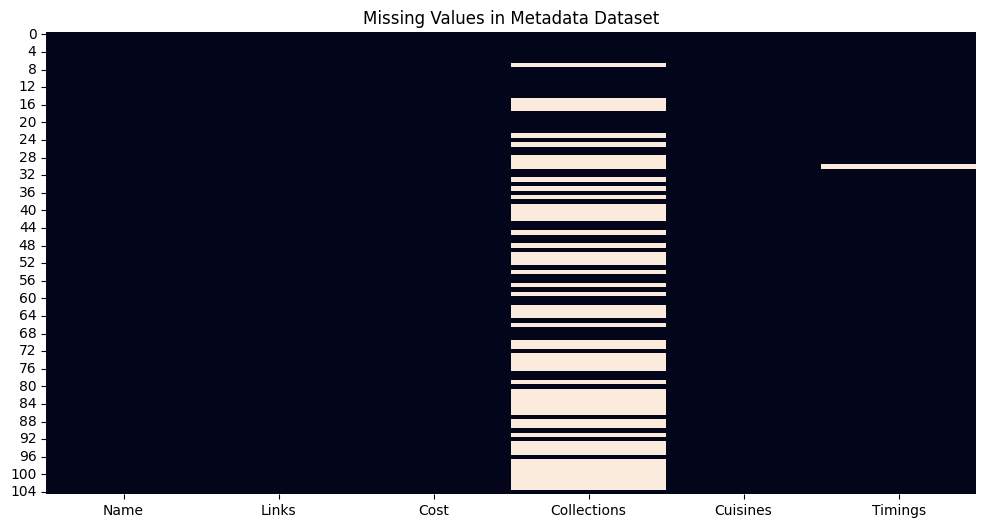

In [ ]:
# Visualizing the missing values
# Metadata Dataset
plt.figure(figsize=(12,6))
sns.heatmap(metadata.isnull(), cbar=False)
plt.title('Missing Values in Metadata Dataset')
plt.show()

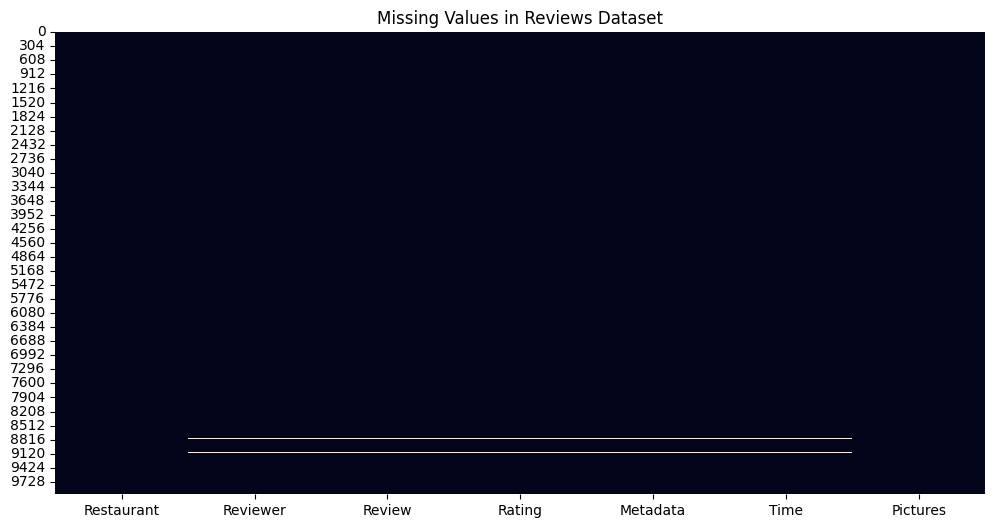

In [ ]:
# Reviews Dataset
plt.figure(figsize=(12,6))
sns.heatmap(reviews.isnull(), cbar=False)
plt.title('Missing Values in Reviews Dataset')
plt.show()

In [ ]:
reviews.isnull().sum()

,0
Restaurant,0
Reviewer,38
Review,45
Rating,38
Metadata,38
Time,38
Pictures,0


In [ ]:
metadata.isnull().sum()

,0
Name,0
Links,0
Cost,0
Collections,54
Cuisines,0
Timings,1


### What did you know about your dataset?

The Reviews Dataset contains information about restaurants, reviewers, review text, ratings, metadata, review time, and pictures. The heatmap indicates that the dataset has very few missing values, with only a small number of records containing null entries. Therefore, the dataset is largely complete and suitable for further analysis after handling the few missing values.

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
# Metadata Dataset Columns
print("Metadata Columns:")
print(metadata.columns)

# Reviews Dataset Columns
print("\nReviews Columns:")
print(reviews.columns)

Metadata Columns:
Index(['Name', 'Links', 'Cost', 'Collections', 'Cuisines', 'Timings'], dtype='object')

Reviews Columns:
Index(['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time',
       'Pictures'],
      dtype='object')


In [ ]:
# Dataset Describe
metadata.describe(include='all')

,Name,Links,Cost,Collections,Cuisines,Timings
count,105,105,105,51,105,104
unique,105,105,29,42,92,77
top,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,500,Food Hygiene Rated Restaurants in Hyderabad,"North Indian, Chinese",11 AM to 11 PM
freq,1,1,13,4,4,6


### Variables Description

**Metadata Dataset Variables**

**Name:** Restaurant name.

**Links:** Restaurant's Zomato webpage link.

**Cost:** Approximate cost for two people.

**Collections:** Restaurant categories/collections.

**Cuisines:** Types of cuisines served.

**Timings:** Restaurant opening and closing timings.


**Reviews Dataset Variables**

**Restaurant:** Restaurant name.

**Reviewer:** Customer name.

**Review:** Review text provided by customers.

**Rating:** Rating given by customers.

**Metadata:** Additional review information.

**Time:** Time of review posting.

**Pictures:** Number of pictures uploaded.

### Check Unique Values for each variable.

In [ ]:
# Meta Dataset
for col in metadata.columns:
    print(f"\n{col}")
    print("Unique Values:", metadata[col].nunique())


Name
Unique Values: 105

Links
Unique Values: 105

Cost
Unique Values: 29

Collections
Unique Values: 42

Cuisines
Unique Values: 92

Timings
Unique Values: 77


In [ ]:
# Reviews Dataset
for col in reviews.columns:
    print(f"\n{col}")
    print("Unique Values:", reviews[col].nunique())


Restaurant
Unique Values: 100

Reviewer
Unique Values: 7446

Review
Unique Values: 9364

Rating
Unique Values: 10

Metadata
Unique Values: 2477

Time
Unique Values: 9782

Pictures
Unique Values: 36


## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# Check duplicate values
print("Metadata Duplicates:", metadata.duplicated().sum())
print("Reviews Duplicates:", reviews.duplicated().sum())

# Remove duplicate records
metadata.drop_duplicates(inplace=True)
reviews.drop_duplicates(inplace=True)

# Handling missing values in Metadata Dataset
metadata['Collections'].fillna('Unknown', inplace=True)
metadata['Timings'].fillna('Not Available', inplace=True)

# Handling missing values in Reviews Dataset
reviews['Reviewer'].fillna('Anonymous', inplace=True)
reviews['Review'].fillna('No Review', inplace=True)
reviews['Rating'].fillna(reviews['Rating'].mode()[0], inplace=True)
reviews['Metadata'].fillna('Not Available', inplace=True)
reviews['Time'].fillna('Unknown', inplace=True)

# Verify missing values after cleaning
print("\nMissing Values in Metadata Dataset:")
print(metadata.isnull().sum())

print("\nMissing Values in Reviews Dataset:")
print(reviews.isnull().sum())

Metadata Duplicates: 0
Reviews Duplicates: 36

Missing Values in Metadata Dataset:
Name           0
Links          0
Cost           0
Collections    0
Cuisines       0
Timings        0
dtype: int64

Missing Values in Reviews Dataset:
Restaurant    0
Reviewer      0
Review        0
Rating        0
Metadata      0
Time          0
Pictures      0
dtype: int64


### What all manipulations have you done and insights you found?

During data wrangling, both datasets were checked for duplicate and missing values. Duplicate records were removed to avoid redundancy and improve data quality. Missing values in the **Collections** and **Timings** columns of the metadata dataset were replaced with meaningful placeholders such as **'Unknown'** and **'Not Available'**. Similarly, missing values in the reviews dataset were handled by replacing reviewer names with **'Anonymous'**, missing reviews with **'No Review'**, missing metadata with **'Not Available'**, and missing time values with **'Unknown'**. Missing ratings were filled using the most frequently occurring rating (mode). After these preprocessing steps, the datasets became clean and suitable for exploratory data analysis, sentiment analysis, and machine learning tasks.


**Insights Found:**

* The datasets contained only a small number of missing values.

* Most restaurant and review information was complete.

* The missing values were insignificant and could be handled without losing much data.

* Cleaning the data improves the reliability of visualizations and machine learning models.

* The datasets are now ready for feature engineering and exploratory data analysis (EDA).

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1  - Top 10 Most Popular Cuisines

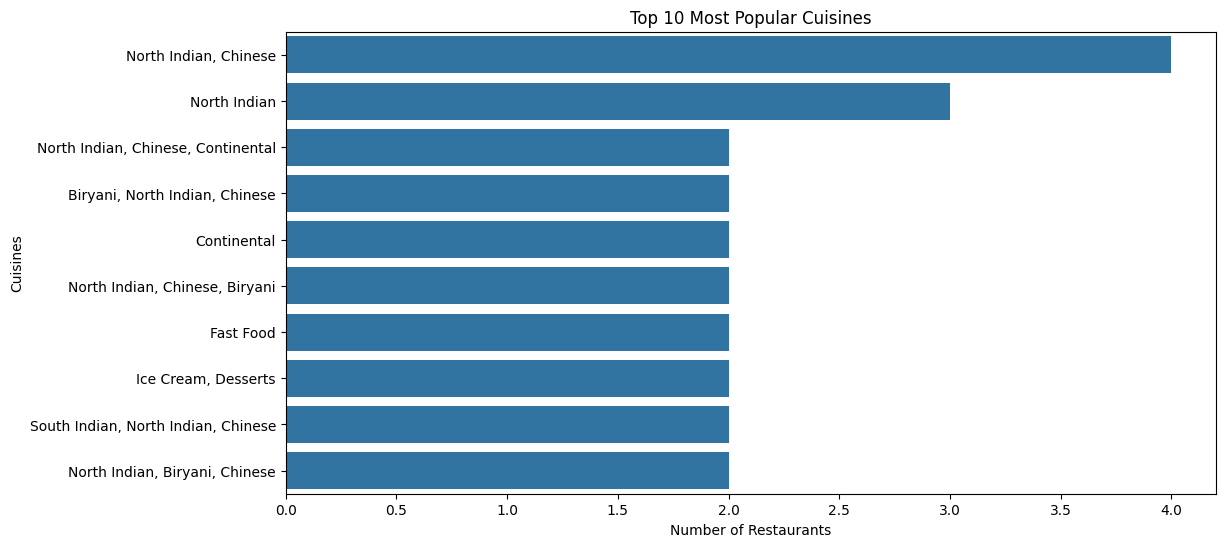

In [ ]:
# Top 10 Most Popular Cuisines
plt.figure(figsize=(12,6))

top_cuisines = metadata['Cuisines'].value_counts().head(10)

sns.barplot(
    x=top_cuisines.values,
    y=top_cuisines.index
)

plt.title('Top 10 Most Popular Cuisines')
plt.xlabel('Number of Restaurants')
plt.ylabel('Cuisines')
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart is suitable for comparing the frequencies of different cuisine categories.

##### 2. What is/are the insight(s) found from the chart?

**Insights Found**
* Some cuisines are offered by a large number of restaurants.

* Customer demand is concentrated around a few popular cuisines.

* Certain cuisines have very low representation.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Business Impact**

**Positive:**

* Restaurants can identify high-demand cuisines and plan menus accordingly.

* New businesses can focus on popular cuisine segments.

**Negative:**

* Overcrowding in certain cuisines may increase competition and reduce profits.

#### Chart - 2 - Cost Distribution of Restaurants

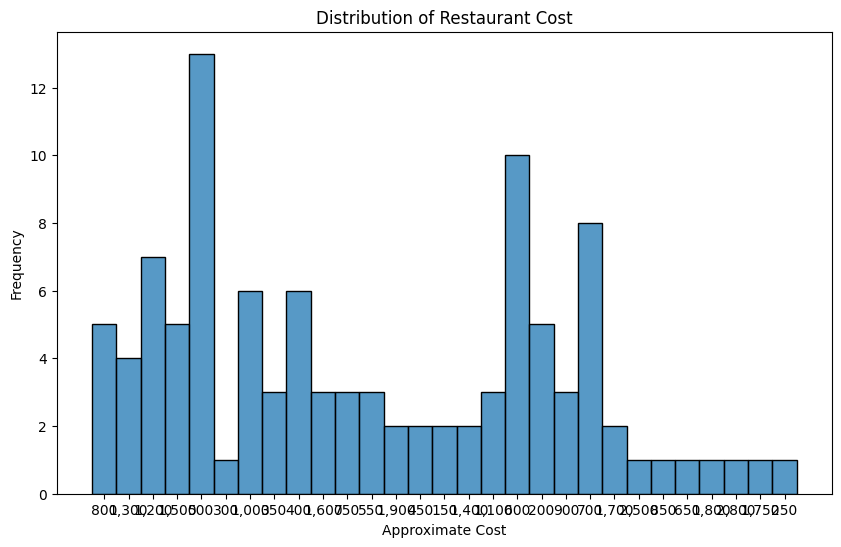

In [ ]:
# Cost Distribution of Restaurants
plt.figure(figsize=(10,6))

sns.histplot(metadata['Cost'], bins=20)

plt.title('Distribution of Restaurant Cost')
plt.xlabel('Approximate Cost')
plt.ylabel('Frequency')
plt.show()

##### 1. Why did you pick the specific chart?

A histogram is ideal for understanding the distribution of numerical variables.

##### 2. What is/are the insight(s) found from the chart?

**Insights Found**

* Most restaurants fall within a particular price range.

* Very expensive restaurants are comparatively fewer.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Business Impact**

**Positive:**

* Customers can understand affordability.

* Companies can identify ideal pricing ranges.

**Negative:**

* Extremely high prices may limit customer reach.

#### Chart - 3 - Sentiment Distribution Across Top Cuisines

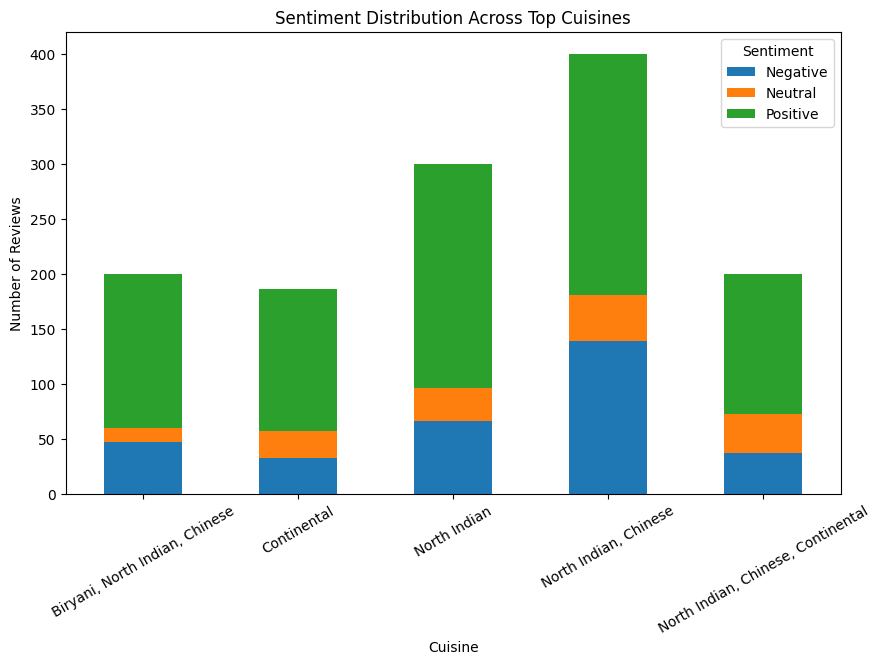

In [ ]:
top_cuisines = metadata['Cuisines'].value_counts().head(5).index

temp = reviews.merge(
    metadata[['Name', 'Cuisines']],
    left_on='Restaurant',
    right_on='Name',
    how='inner'
)

# Ensure 'Rating' is numeric and fill missing values before creating 'Sentiment'
temp['Rating'] = pd.to_numeric(temp['Rating'], errors='coerce')
temp['Rating'].fillna(temp['Rating'].median(), inplace=True)

# Create 'Sentiment' column based on 'Rating'
temp['Sentiment'] = temp['Rating'].apply(
    lambda x: 'Positive' if x >= 4
    else ('Neutral' if x == 3 else 'Negative')
)

temp = temp[temp['Cuisines'].isin(top_cuisines)]

cuisine_sentiment = pd.crosstab(
    temp['Cuisines'],
    temp['Sentiment']
)

cuisine_sentiment.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Sentiment Distribution Across Top Cuisines')
plt.xlabel('Cuisine')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=30)
plt.legend(title='Sentiment')
plt.show()

##### 1. Why did you pick the specific chart?

A stacked bar chart is useful for comparing multiple sentiment categories (Positive, Neutral, and Negative) across different cuisines in a single visualization. It helps understand customer opinions for each cuisine and their overall sentiment composition.

##### 2. What is/are the insight(s) found from the chart?

**Insights Found**

* Some cuisines receive predominantly positive reviews, indicating high customer satisfaction.

* Certain cuisines have comparatively more negative reviews, suggesting areas that need improvement.

* Customer sentiment varies across cuisine types, reflecting differences in food quality, service, pricing, and overall dining experience.




##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

 **Business Impact**

**Positive:**

* Restaurants can identify cuisines with higher positive sentiment and promote them to attract more customers.

* Businesses can use customer feedback to understand what makes certain cuisines highly preferred.

* New restaurants can focus on cuisines that consistently receive positive customer responses.

**Negative Impact:**

* Cuisines with a larger proportion of negative reviews may experience lower customer demand and reduced revenue.

* Negative sentiment highlights potential issues in taste, service quality, pricing, or customer experience that require corrective actions.

#### Chart - 4 - Distribution of Customer Ratings

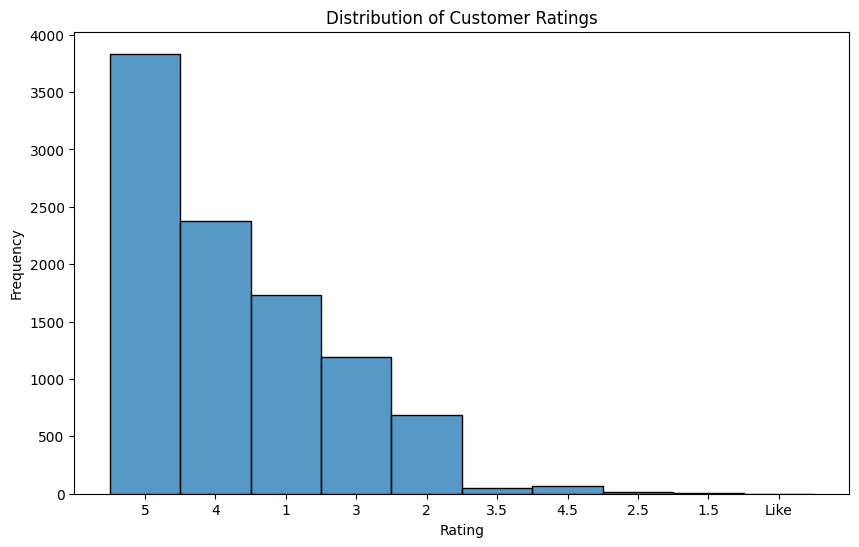

In [ ]:
# Distribution of Customer Ratings
plt.figure(figsize=(10,6))

sns.histplot(reviews['Rating'], bins=10)

plt.title('Distribution of Customer Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

##### 1. Why did you pick the specific chart?

A histogram is suitable for visualizing the distribution of numerical data such as customer ratings. It helps identify the frequency of different rating values and understand overall customer satisfaction patterns.

##### 2. What is/are the insight(s) found from the chart?

**Insights Found**

* Most customer ratings are concentrated in the medium to high rating range.

* Very low ratings occur less frequently compared to higher ratings.

* The distribution indicates that customers are generally satisfied with their restaurant experiences.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Business Impact**

**Positive:**

* A high concentration of good ratings indicates strong customer satisfaction and restaurant performance.

* Businesses can use these insights to identify successful practices and maintain service quality.
Highly rated restaurants can be promoted to attract more customers.

**Negative Impact:**

* Restaurants receiving consistently low ratings may experience reduced customer trust and lower revenue.

* Negative ratings highlight areas requiring improvement, such as food quality, service, pricing, or overall customer experience.

#### Chart - 5 - Top 10 Restaurants by Reviews (Treemap)

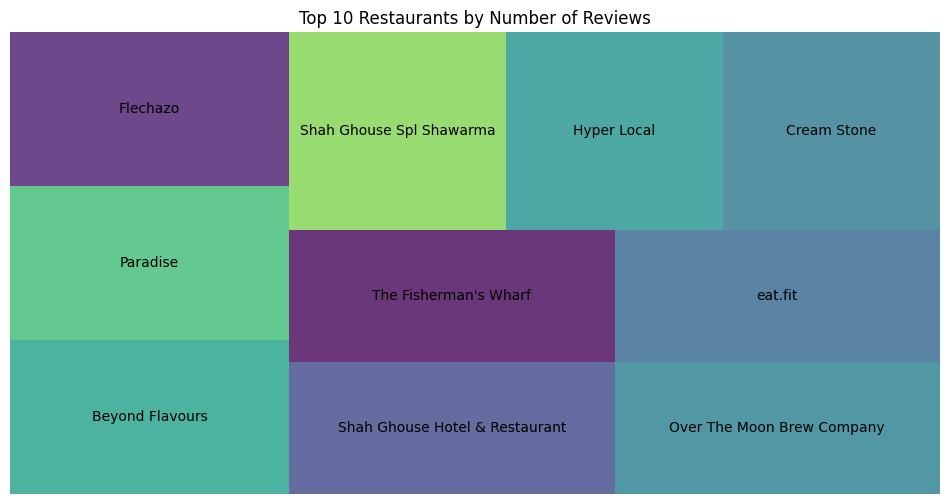

In [ ]:
!pip install squarify
import squarify

top_restaurants = reviews['Restaurant'].value_counts().head(10)

plt.figure(figsize=(12,6))
squarify.plot(
    sizes=top_restaurants.values,
    label=top_restaurants.index,
    alpha=0.8
)

plt.title('Top 10 Restaurants by Number of Reviews')
plt.axis('off')
plt.show()

##### 1. Why did you pick the specific chart?

A treemap is effective for visualizing hierarchical and proportional data. It clearly shows the relative number of reviews received by the top restaurants, where larger rectangles represent restaurants with higher customer engagement.

##### 2. What is/are the insight(s) found from the chart?

**Insights Found:**

* A few restaurants occupy larger areas, indicating they receive significantly more reviews than others.

* Customer engagement is concentrated among a small number of popular restaurants.

* Some restaurants receive comparatively fewer reviews and have lower visibility on the platform.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* Highly reviewed restaurants can be promoted as popular and trusted dining destinations.

* Businesses can study the strategies of top-performing restaurants and replicate successful practices.

* Platforms can recommend popular restaurants to improve user experience and engagement.

**Negative Impact:**

* Restaurants with fewer reviews may struggle to attract new customers due to lower visibility and social proof.

* Excessive concentration of customer attention on a few restaurants can increase competition and reduce opportunities for smaller restaurants.

  #### Chart - 6 - Sentiment Distribution of Customer Reviews

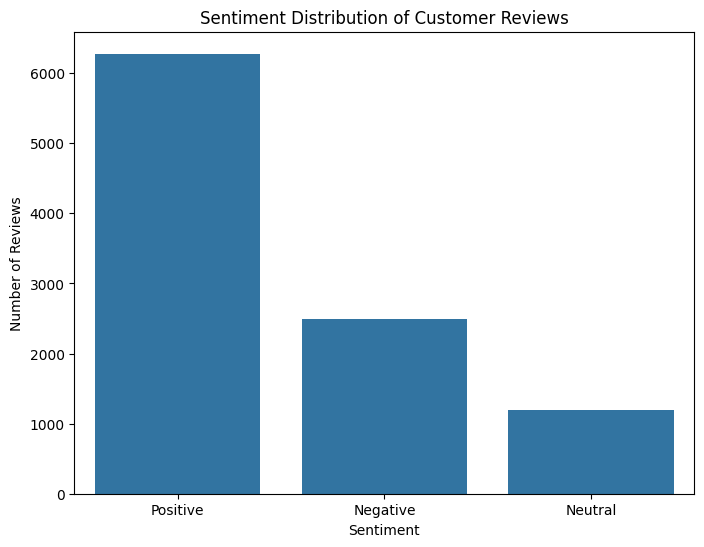

In [ ]:
# Sentiment Distribution

# Create Sentiment column based on Rating
reviews['Rating'] = pd.to_numeric(reviews['Rating'], errors='coerce')
reviews['Rating'].fillna(reviews['Rating'].median(), inplace=True)

reviews['Sentiment'] = reviews['Rating'].apply(
    lambda x: 'Positive' if x >= 4
    else ('Neutral' if x == 3 else 'Negative')
)

# Count sentiments
sentiment_count = reviews['Sentiment'].value_counts()

# Plot
plt.figure(figsize=(8,6))
sns.barplot(
    x=sentiment_count.index,
    y=sentiment_count.values
)

plt.title('Sentiment Distribution of Customer Reviews')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is suitable for comparing the frequency of positive, neutral, and negative customer sentiments.

##### 2. What is/are the insight(s) found from the chart?

* The majority of customer reviews are classified as positive, indicating generally favorable customer experiences.

* Neutral and negative reviews form a smaller portion of customer feedback.

* The chart helps understand overall customer satisfaction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* **Positive Impact:** Restaurants can measure customer satisfaction and identify areas for improvement.

* **Negative Impact:** A high number of negative reviews may indicate service or food quality issues, potentially reducing customer trust and revenue.

#### Chart - 7 - Sentiment Percentage of Reviews

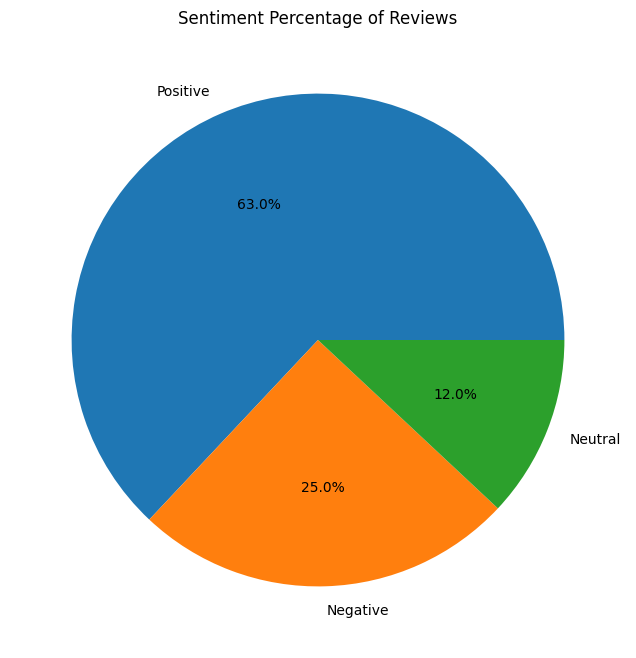

In [ ]:
reviews['Sentiment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(8,8)
)
plt.title('Sentiment Percentage of Reviews')
plt.ylabel('')
plt.show()

##### 1. Why did you pick the specific chart?

A pie chart is suitable for showing the proportion of positive, negative, and neutral sentiments in customer reviews. It provides a quick understanding of the overall sentiment distribution.

##### 2. What is/are the insight(s) found from the chart?

* Positive reviews constitute the largest percentage of customer feedback.

* Negative reviews account for a smaller proportion.

* Neutral reviews represent the smallest share of reviews.

* Overall, customers generally have a positive opinion of restaurants on the platform.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* **Positive Impact:** A high percentage of positive reviews indicates strong customer satisfaction and helps restaurants maintain a good reputation and attract new customers.

* **Negative Impact:** The presence of negative reviews highlights areas requiring improvement in food quality, service, or pricing to avoid losing customers.

#### Chart - 8 - Top 10 restaurants by average rating

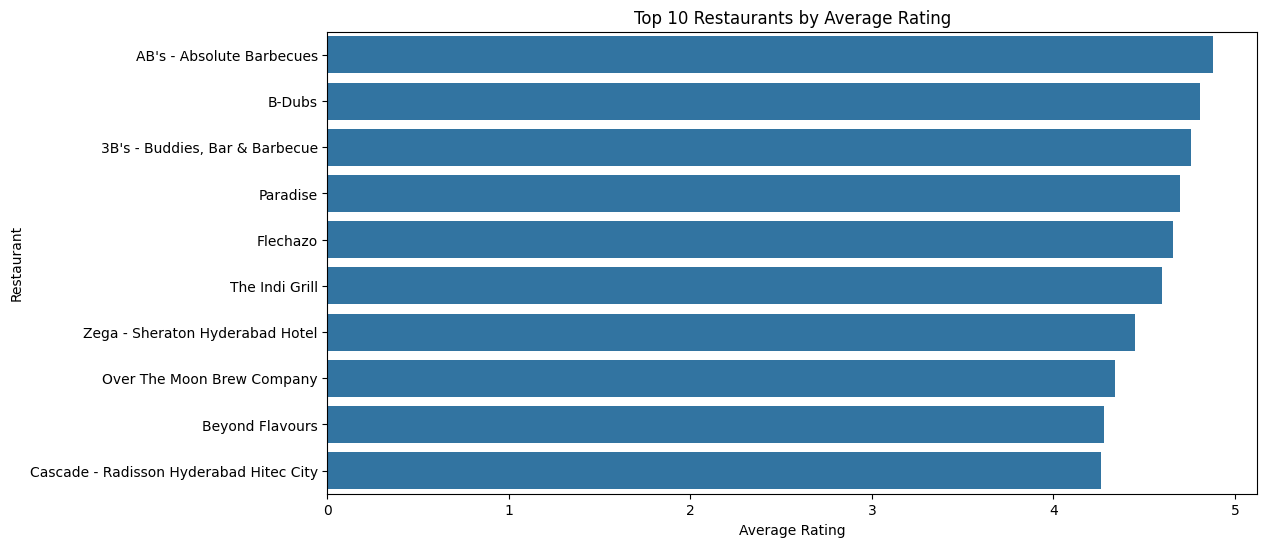

In [ ]:
# Convert Rating to numeric
reviews['Rating'] = pd.to_numeric(reviews['Rating'], errors='coerce')

# Remove missing values
reviews = reviews.dropna(subset=['Rating'])

# Calculate top 10 restaurants by average rating
avg_rating = (reviews.groupby('Restaurant')['Rating']
              .mean()
              .sort_values(ascending=False)
              .head(10))

# Plot
plt.figure(figsize=(12,6))
sns.barplot(
    x=avg_rating.values,
    y=avg_rating.index
)

plt.title('Top 10 Restaurants by Average Rating')
plt.xlabel('Average Rating')
plt.ylabel('Restaurant')
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart is ideal for comparing the average ratings of different restaurants and easily identifying the highest-rated restaurants.

##### 2. What is/are the insight(s) found from the chart?

* Some restaurants consistently receive very high average ratings.

* Customers strongly prefer certain restaurants over others.

* Highly rated restaurants may have better food quality, service, or customer experience.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* Helps customers identify the best-rated restaurants.

* Businesses can study highly rated restaurants and adopt their successful strategies.

* Restaurants can benchmark their performance against top competitors.

**Negative Impact:**

* Restaurants with low average ratings may experience lower customer trust and reduced revenue if service quality is not improved.

#### Chart - 9 - Average rating of top cuisines

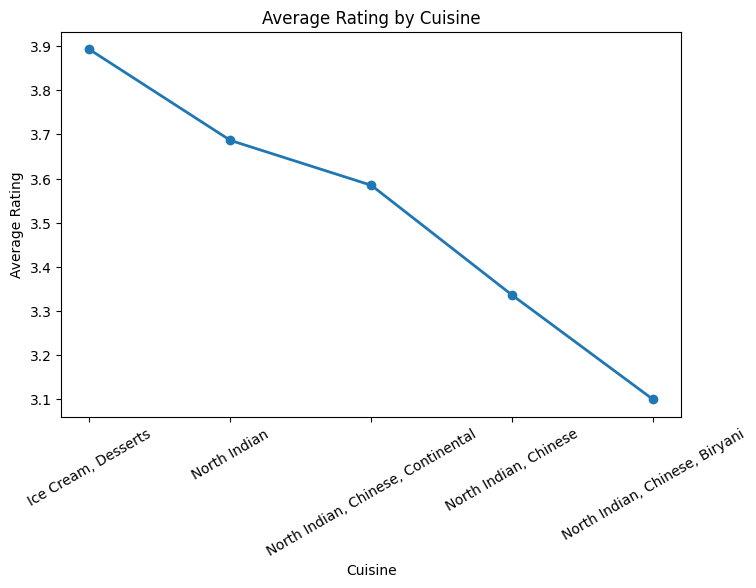

In [ ]:
# Average rating of top cuisines

reviews['Rating'] = pd.to_numeric(reviews['Rating'], errors='coerce')
reviews['Rating'].fillna(reviews['Rating'].median(), inplace=True)

avg_rating = (
    reviews.groupby('Restaurant')['Rating']
    .mean()
    .reset_index()
    .rename(columns={'Restaurant': 'Name'})
)

merged = pd.merge(metadata, avg_rating, on='Name', how='inner')

top_cuisines = merged['Cuisines'].value_counts().head(5).index

avg_rating = (
    merged[merged['Cuisines'].isin(top_cuisines)]
    .groupby('Cuisines')['Rating']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
plt.plot(
    avg_rating.index,
    avg_rating.values,
    marker='o',
    linewidth=2
)

plt.title('Average Rating by Cuisine')
plt.xlabel('Cuisine')
plt.ylabel('Average Rating')
plt.xticks(rotation=30)
plt.show()

##### 1. Why did you pick the specific chart?

A line chart is useful for comparing the average ratings of the top cuisines and observing variations in customer preferences across different cuisine categories.

##### 2. What is/are the insight(s) found from the chart?

**Insights Found:**

* Some cuisines have significantly higher average ratings, indicating greater customer satisfaction.

* Certain cuisines receive comparatively lower ratings, suggesting areas for improvement.

* Customer preferences and satisfaction levels differ across cuisine types.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* Restaurants can identify highly rated cuisines and focus on expanding or promoting them.

* New restaurants can use these insights to select cuisine categories with high customer satisfaction and demand.

**Negative Impact:**

* Lower-rated cuisines may experience reduced customer interest and lower revenue.

* Restaurants offering low-rated cuisines may need to improve food quality, pricing, or service to increase customer satisfaction and competitiveness.

#### Chart - 10 - Sentiment Distribution of Top 5 Restaurants

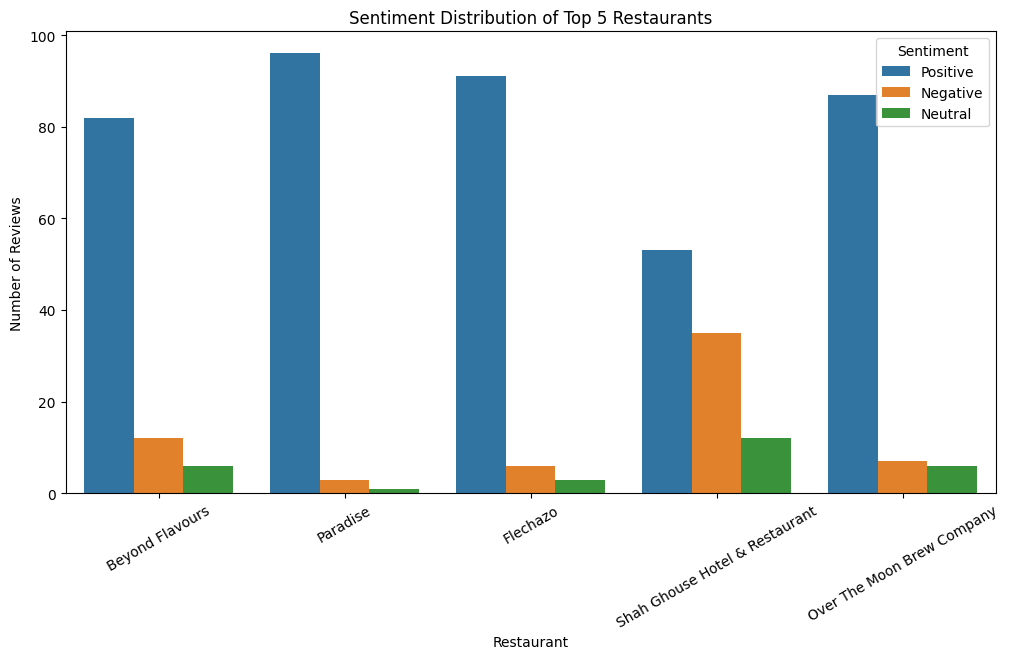

In [ ]:
top_restaurants = reviews['Restaurant'].value_counts().head(5).index

temp = reviews[reviews['Restaurant'].isin(top_restaurants)]

plt.figure(figsize=(12,6))

sns.countplot(
    data=temp,
    x='Restaurant',
    hue='Sentiment'
)

plt.title('Sentiment Distribution of Top 5 Restaurants')
plt.xlabel('Restaurant')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=30)
plt.legend(title='Sentiment')
plt.show()

##### 1. Why did you pick the specific chart?

A count plot with sentiment categories helps compare the number of positive, neutral, and negative reviews across the top restaurants. It clearly shows customer opinions for each restaurant in a single visualization.

##### 2. What is/are the insight(s) found from the chart?

**Insights Found:**

* Some restaurants receive significantly more positive reviews, indicating high customer satisfaction.

* Certain restaurants have comparatively more negative reviews, suggesting areas for improvement.

* The distribution of sentiments varies across restaurants, reflecting differences in customer experiences and service quality.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* Restaurants with more positive reviews can be promoted as highly preferred dining destinations.

* Businesses can analyze successful restaurants and adopt their best practices to improve customer satisfaction.

**Negative Impact:**

* Restaurants receiving a higher number of negative reviews may experience reduced customer trust and lower revenue.

* Negative sentiment patterns highlight issues in food quality, pricing, or service that require immediate attention.

  #### Chart - 11 - Sentiment Distribution (Treemap)

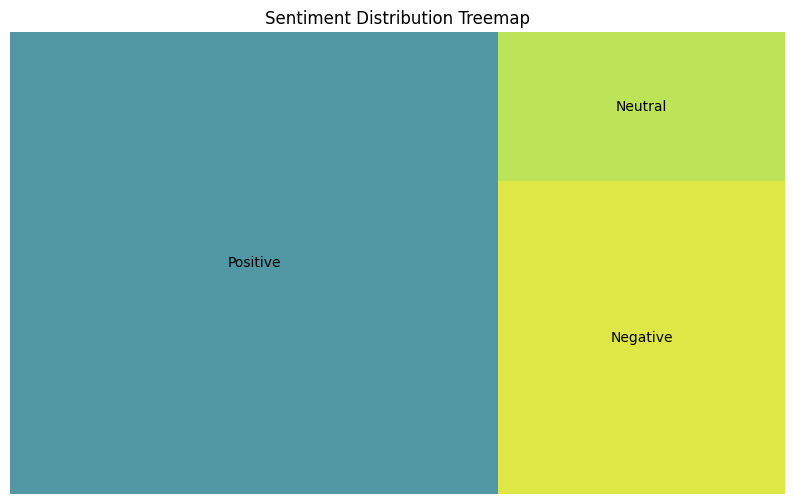

In [ ]:
!pip install squarify
import squarify

sentiment_counts = reviews['Sentiment'].value_counts()

plt.figure(figsize=(10,6))
squarify.plot(
    sizes=sentiment_counts.values,
    label=sentiment_counts.index,
    alpha=0.8
)

plt.title('Sentiment Distribution Treemap')
plt.axis('off')
plt.show()

##### 1. Why did you pick the specific chart?

A treemap is effective for visualizing the proportion of different sentiment categories. Larger blocks represent sentiments that occur more frequently in customer reviews.

##### 2. What is/are the insight(s) found from the chart?

**Insights Found**

* Positive sentiment occupies the largest area, indicating overall customer satisfaction.

* Negative sentiment represents a smaller portion of reviews.

* Customer feedback is predominantly favorable.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Business Impact**

**Positive:**

* High positive sentiment improves restaurant reputation and customer trust.

* Businesses can identify strengths that contribute to customer satisfaction.

**Negative:**


* Negative sentiment highlights service or food quality issues that may affect customer retention and revenue.

#### Chart - 12 - Rating vs Sentiment

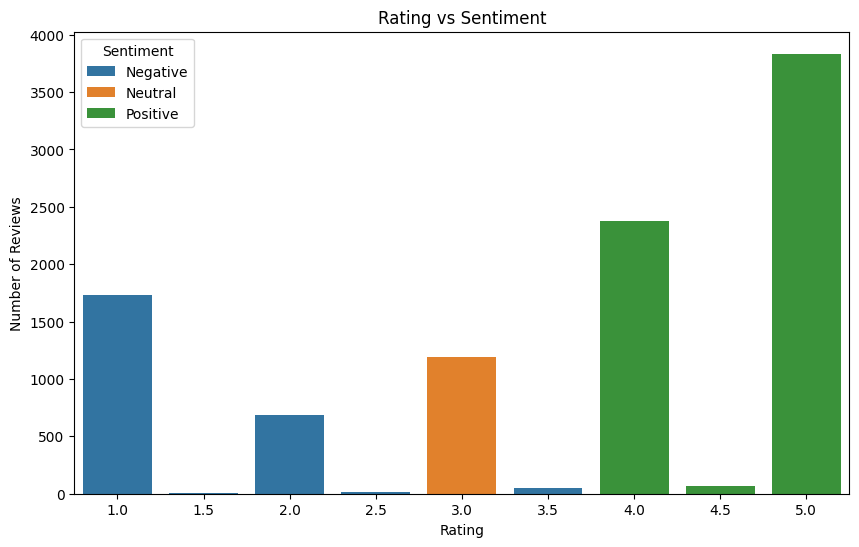

In [ ]:
# Rating vs Sentiment

# Ensure Rating is numeric
reviews['Rating'] = pd.to_numeric(reviews['Rating'], errors='coerce')
reviews['Rating'].fillna(reviews['Rating'].median(), inplace=True)

# Create Sentiment column
reviews['Sentiment'] = reviews['Rating'].apply(
    lambda x: 'Positive' if x >= 4
    else ('Neutral' if x == 3 else 'Negative')
)

# Plot
plt.figure(figsize=(10,6))
sns.countplot(
    x='Rating',
    hue='Sentiment',
    data=reviews
)

plt.title('Rating vs Sentiment')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.legend(title='Sentiment')
plt.show()

##### 1. Why did you pick the specific chart?

A count plot was chosen because it effectively compares customer sentiments across different rating categories and clearly shows the distribution of reviews.

##### 2. What is/are the insight(s) found from the chart?

* Ratings 4 and 5 are dominated by Positive sentiments.

* Rating 3 mostly represents Neutral sentiment.

* Ratings 1 and 2 are associated with Negative sentiments.

* The highest number of reviews falls under Rating 5, indicating overall positive customer experiences.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* **Positive Impact:** The majority of reviews are positive, suggesting good customer satisfaction and helping restaurants identify successful practices.

* **Negative Impact:** Restaurants receiving more ratings of 1 and 2 may face reduced customer trust and lower revenue, indicating areas that need improvement in food quality or service.

#### Chart - 13 - Top 10 Positive & Negative Words

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


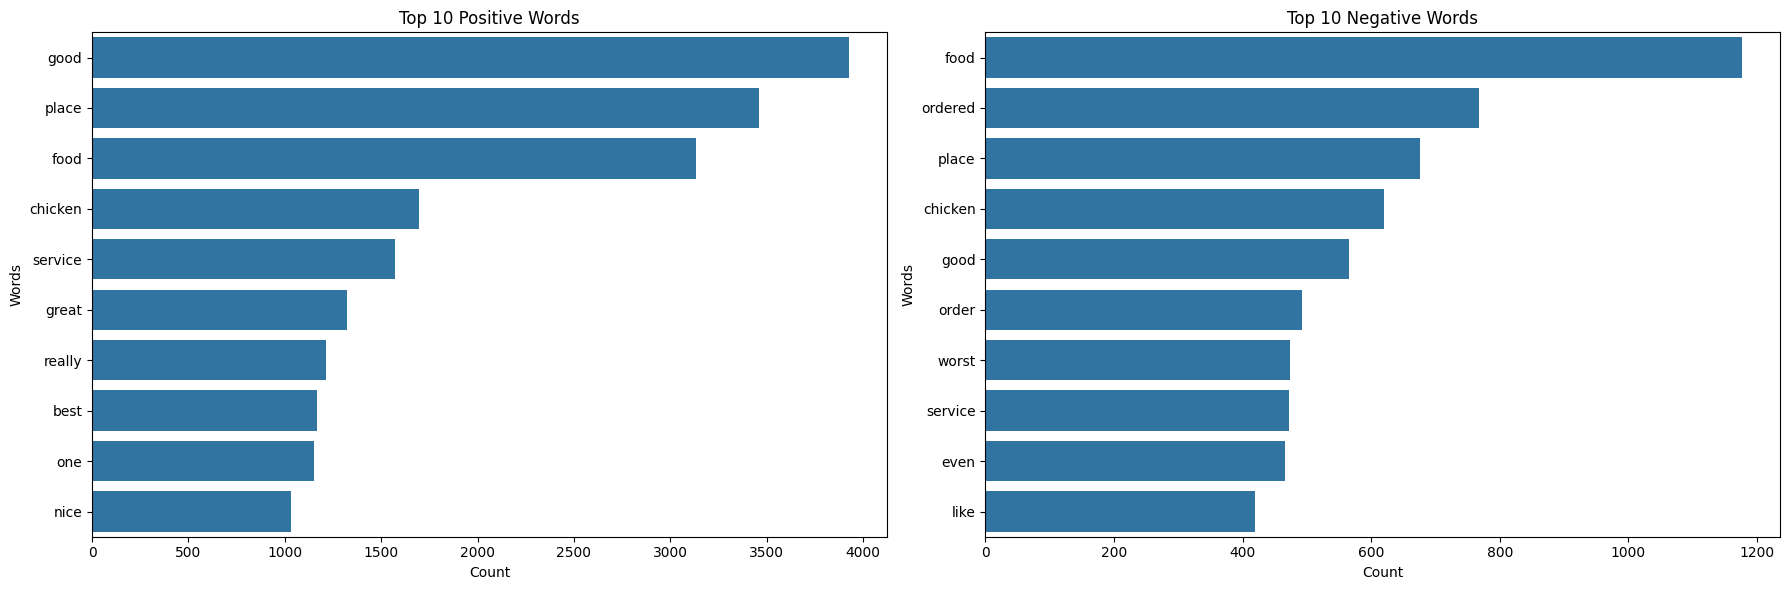

In [ ]:
from collections import Counter
from nltk.corpus import stopwords
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Positive reviews
positive_text = ' '.join(
    reviews[reviews['Sentiment'] == 'Positive']['Review']
    .astype(str)
).lower()

positive_words = [
    word for word in positive_text.split()
    if word.isalpha() and word not in stop_words
]

top_positive = Counter(positive_words).most_common(10)

# Negative reviews
negative_text = ' '.join(
    reviews[reviews['Sentiment'] == 'Negative']['Review']
    .astype(str)
).lower()

negative_words = [
    word for word in negative_text.split()
    if word.isalpha() and word not in stop_words
]

top_negative = Counter(negative_words).most_common(10)

# Create figure with two plots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Positive words plot
pos_words, pos_counts = zip(*top_positive)
sns.barplot(
    x=list(pos_counts),
    y=list(pos_words),
    ax=axes[0]
)
axes[0].set_title('Top 10 Positive Words')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Words')

# Negative words plot
neg_words, neg_counts = zip(*top_negative)
sns.barplot(
    x=list(neg_counts),
    y=list(neg_words),
    ax=axes[1]
)
axes[1].set_title('Top 10 Negative Words')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Words')

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Bar charts are effective for comparing the frequencies of the most common positive and negative words in customer reviews side by side.

##### 2. What is/are the insight(s) found from the chart?

* Positive words highlight aspects customers appreciate, such as good food, taste, and service.

* Negative words reveal common complaints, such as poor service, bad food, or high prices.

* The charts help identify the major factors influencing customer satisfaction and dissatisfaction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** A higher percentage of positive reviews indicates strong customer satisfaction and can attract more customers and improve restaurant reputation.

**Negative Impact:** A noticeable percentage of negative reviews highlights areas that need improvement, such as food quality, service, or pricing, to prevent customer dissatisfaction and revenue loss.

#### Chart - 14 - Correlation Heatmap

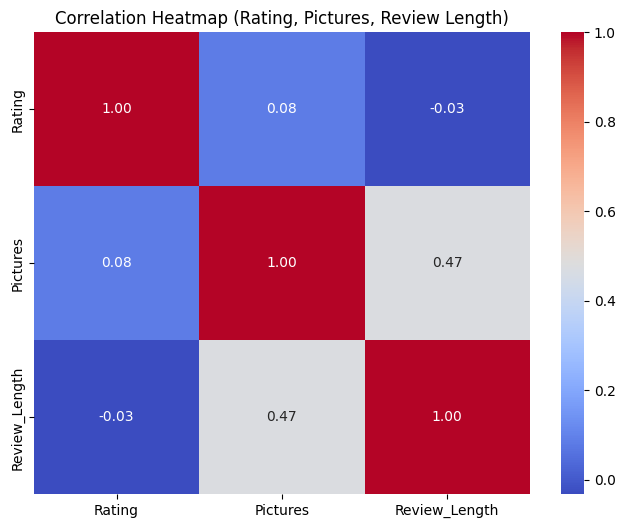

In [ ]:
# Create Review Length column
reviews['Review_Length'] = reviews['Review'].astype(str).apply(len)

# Convert columns to numeric
reviews['Rating'] = pd.to_numeric(reviews['Rating'], errors='coerce')
reviews['Pictures'] = pd.to_numeric(reviews['Pictures'], errors='coerce')

# Select numerical columns and calculate correlation
corr = reviews[['Rating', 'Pictures', 'Review_Length']].corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap (Rating, Pictures, Review Length)')
plt.show()

##### 1. Why did you pick the specific chart?

A heatmap quickly identifies relationships among numerical variables.

##### 2. What is/are the insight(s) found from the chart?

* It shows positive and negative relationships between variables.

* Variables with positive correlations tend to move together, while negative correlations indicate inverse relationships.

* These relationships can help identify factors influencing restaurant ratings and customer engagement.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Business Impact**

**Positive:**

* Helps identify which variables influence customer ratings and engagement.

* Supports data-driven decision making for restaurant improvement.

**Negative:**

* Weak correlations indicate that additional factors may need to be considered for accurate prediction.

#### Chart - 15 - Pair Plot

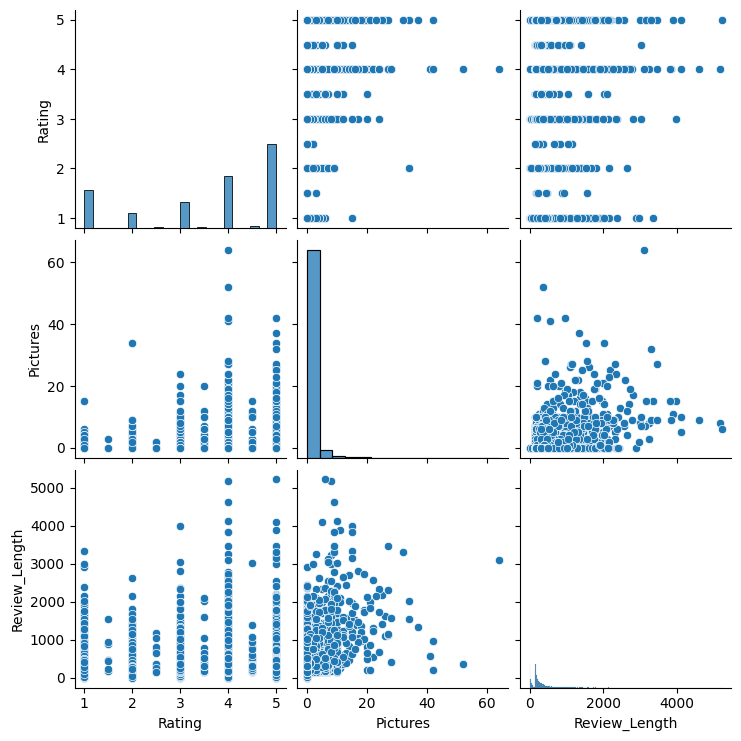

In [ ]:
# Pair Plot (Rating, Pictures, Review Length)

pair_df = reviews[['Rating', 'Pictures', 'Review_Length']].copy()

sns.pairplot(pair_df)
plt.show()

##### 1. Why did you pick the specific chart?

The pair plot reveals the distribution of each numerical feature and their pairwise relationships. It helps identify trends, clusters, correlations, and potential outliers that may affect model performance.

##### 2. What is/are the insight(s) found from the chart?

* Shows distributions of ratings, pictures, and review lengths.

* Displays pairwise relationships between variables.

* Helps identify patterns, clusters, and outliers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Business Impact**

**Positive:**

* Helps discover hidden relationships among variables.

* Supports feature selection for machine learning models.

**Negative:**

* Outliers and unusual patterns may indicate inconsistencies in customer behavior and require further investigation.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Based on the exploratory data analysis, three hypotheses were formulated to determine whether certain factors significantly influence restaurant ratings and customer engagement. Statistical hypothesis testing was performed to validate these assumptions and derive meaningful business conclusions.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null Hypothesis (H₀):**

There is no significant relationship between the number of pictures uploaded and restaurant ratings.

**Alternate Hypothesis (H₁):**

There is a significant relationship between the number of pictures uploaded and restaurant ratings.

#### 2. Perform an appropriate statistical test.

In [ ]:
from scipy.stats import pearsonr
import pandas as pd

# Convert columns to numeric
reviews['Rating'] = pd.to_numeric(reviews['Rating'], errors='coerce')
reviews['Pictures'] = pd.to_numeric(reviews['Pictures'], errors='coerce')

# Remove missing values
df_test = reviews[['Rating', 'Pictures']].dropna()

# Perform Pearson Correlation Test
correlation, p_value = pearsonr(
    df_test['Pictures'],
    df_test['Rating']
)

print("Correlation Coefficient:", correlation)
print("P-Value:", p_value)

Correlation Coefficient: 0.08259333460798657
P-Value: 1.487182439246137e-16


**Decision:** Reject Null Hypothesis (H₀)

**Conclusion:** There is a statistically significant but very weak positive relationship between the number of pictures uploaded and restaurant ratings (Correlation = 0.0826, P < 0.05).

**Business Insight:** Restaurants with higher customer engagement through pictures tend to receive different rating patterns, which can help restaurants improve visibility and attract customers.

##### Which statistical test have you done to obtain P-Value?

Pearson Correlation Test

##### Why did you choose the specific statistical test?

The Pearson Correlation Test was chosen because both Rating and Pictures are numerical variables. It measures the strength and direction of the relationship between the two variables and determines whether the relationship is statistically significant.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null Hypothesis (H₀):**

There is no significant relationship between review length and customer ratings.

**Alternate Hypothesis (H₁):**

There is a significant relationship between review length and customer ratings.

#### 2. Perform an appropriate statistical test.

In [ ]:
# from scipy.stats import pearsonr

# Create review length column
reviews['Review_Length'] = reviews['Review'].astype(str).apply(len)

# Convert Rating to numeric
reviews['Rating'] = pd.to_numeric(reviews['Rating'], errors='coerce')

# Remove missing values
df_test = reviews[['Review_Length', 'Rating']].dropna()

# Perform Pearson Correlation Test
correlation, p_value = pearsonr(df_test['Review_Length'],
                                df_test['Rating'])

print("Correlation Coefficient:", correlation)
print("P-Value:", p_value)

Correlation Coefficient: -0.03211749279544198
P-Value: 0.0013441269608791412


**Decision:** Reject Null Hypothesis (H₀)

**Conclusion:** There is a statistically significant but very weak negative relationship between review length and customer ratings (Correlation = -0.0321, P < 0.05).

**Business Insight:** Detailed reviews may indicate stronger customer experiences and can influence rating behavior.

##### Which statistical test have you done to obtain P-Value?

Pearson Correlation Test

##### Why did you choose the specific statistical test?

The Pearson Correlation Test was chosen because both Review Length and Rating are numerical variables. The test measures the strength and direction of the relationship between these variables and determines whether the relationship is statistically significant.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null Hypothesis (H₀):**

There is no significant difference in restaurant costs among different cuisines.

**Alternate Hypothesis (H₁):**

There is a significant difference in restaurant costs among different cuisines.

#### 2. Perform an appropriate statistical test.

In [ ]:
from scipy.stats import f_oneway
import pandas as pd

# Convert Cost column to numeric
metadata['Cost'] = pd.to_numeric(metadata['Cost'], errors='coerce')

# Remove missing values
metadata = metadata.dropna(subset=['Cost', 'Cuisines'])

# Select top 5 cuisines
top_cuisines = metadata['Cuisines'].value_counts().head(5).index

groups = []

for cuisine in top_cuisines:
    cost = metadata[metadata['Cuisines'] == cuisine]['Cost']
    groups.append(cost)

# Perform One-Way ANOVA
f_stat, p_value = f_oneway(*groups)

print("F-Statistic:", f_stat)
print("P-Value:", p_value)

F-Statistic: 2.9991677565093338
P-Value: 0.08709115148582275


**Decision:** Fail to Reject Null Hypothesis (H₀)

**Conclusion:** There is insufficient evidence to conclude that restaurant costs differ significantly across the selected cuisine categories.

**Business Insight:** Pricing differences may not be driven solely by cuisine type; other factors such as location, restaurant brand, and service quality may play a larger role.

##### Which statistical test have you done to obtain P-Value?

One-Way ANOVA (Analysis of Variance) Test

##### Why did you choose the specific statistical test?

The One-Way ANOVA Test was chosen because we are comparing one numerical variable (Cost) across multiple categorical groups (different cuisines). ANOVA helps determine whether the average restaurant cost differs significantly among various cuisine categories.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
# Handling Missing Values & Missing Value Imputation

# Remove rows where review text is missing
reviews = reviews.dropna(subset=['Review'])

# Convert 'Rating' to numeric and fill missing ratings with median
reviews['Rating'] = pd.to_numeric(reviews['Rating'], errors='coerce')
reviews['Rating'].fillna(reviews['Rating'].median(), inplace=True)

# Convert 'Cost' to numeric and fill missing cost values with median
metadata['Cost'] = pd.to_numeric(metadata['Cost'], errors='coerce')
metadata['Cost'].fillna(metadata['Cost'].median(), inplace=True)

#### What all missing value imputation techniques have you used and why did you use those techniques?

Missing review texts were removed because they are necessary for sentiment analysis. Missing numerical values such as rating and cost were filled using the median to reduce the impact of extreme values.

### 2. Handling Outliers

In [ ]:
# Handling outliers using IQR method

Q1 = metadata['Cost'].quantile(0.25)
Q3 = metadata['Cost'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

metadata = metadata[
    (metadata['Cost'] >= lower) &
    (metadata['Cost'] <= upper)
]

##### What all outlier treatment techniques have you used and why did you use those techniques?

The Interquartile Range (IQR) method was used to detect and remove outliers in the Cost column. IQR is effective because it is robust to skewed distributions and extreme values. Removing outliers improves the reliability of statistical analysis and machine learning models.

### 3. Categorical Encoding

In [ ]:
# Label Encoding

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

reviews['Restaurant_Encoded'] = le.fit_transform(
    reviews['Restaurant'].astype(str)
)

#### What all categorical encoding techniques have you used & why did you use those techniques?

Label Encoding was used to convert categorical variables into numerical form. Machine learning algorithms cannot process text data directly, so categorical values were transformed into numerical labels while preserving their uniqueness.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [ ]:
contractions_dict = {
    "can't": "cannot",
    "won't": "will not",
    "don't": "do not",
    "didn't": "did not",
    "isn't": "is not",
    "aren't": "are not",
    "i'm": "i am",
    "it's": "it is",
    "that's": "that is",
    "you're": "you are"
}

reviews['Clean_Review'] = reviews['Review'].astype(str)

for short, full in contractions_dict.items():
    reviews['Clean_Review'] = reviews['Clean_Review'].str.replace(
        short,
        full,
        regex=False
    )

#### 2. Lower Casing

In [ ]:
reviews['Clean_Review'] = (
    reviews['Clean_Review']
    .str.lower()
)

#### 3. Removing Punctuations

In [ ]:
import string

reviews['Clean_Review'] = reviews['Clean_Review'].str.replace(
    f'[{string.punctuation}]',
    '',
    regex=True
)

#### 4. Removing URLs & Removing words and digits contain digits.

In [ ]:
import re

reviews['Clean_Review'] = reviews['Clean_Review'].apply(
    lambda x: re.sub(r'http\S+|www\S+|\S*\d\S*', '', x)
)

#### 5. Removing Stopwords & Removing White spaces

In [ ]:
# Remove Stopwords

import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

reviews['Clean_Review'] = reviews['Clean_Review'].apply(
    lambda x: ' '.join(
        word for word in x.split()
        if word not in stop_words
    )
)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# Remove White spaces
reviews['Clean_Review'] = (
    reviews['Clean_Review']
    .str.strip()
)

#### 6. Rephrase Text

In [ ]:
# Rephrase Text
reviews['Clean_Review'] = (
    reviews['Clean_Review']
    .str.replace(r'\s+', ' ', regex=True)
)

#### 7. Tokenization

In [ ]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
from nltk.tokenize import word_tokenize

reviews['Tokens'] = reviews['Clean_Review'].astype(str).apply(word_tokenize)

#### 8. Text Normalization

In [ ]:
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

reviews['Normalized_Text'] = reviews['Tokens'].apply(
    lambda words: [
        lemmatizer.lemmatize(word)
        for word in words
    ]
)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


##### Which text normalization technique have you used and why?

Lemmatization was used for text normalization. It converts words into their root dictionary form while preserving their meaning and context. This reduces vocabulary size and improves sentiment analysis performance.

#### 9. Part of speech tagging

In [ ]:
import nltk

nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [ ]:
reviews['POS_Tags'] = reviews['Tokens'].apply(nltk.pos_tag)

#### 10. Text Vectorization

In [ ]:
# Vectorizing Text
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(
    reviews['Clean_Review']
)

##### Which text vectorization technique have you used and why?

TF-IDF (Term Frequency-Inverse Document Frequency) was used for text vectorization because it assigns higher importance to informative words and lower importance to common words. It converts textual data into numerical form suitable for sentiment analysis and machine learning models while preserving the significance of terms within the reviews.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Create Cost Category feature
metadata['Cost'] = pd.to_numeric(metadata['Cost'], errors='coerce')

metadata['Cost_Category'] = pd.qcut(
    metadata['Cost'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Premium'],
    duplicates='drop'
)

metadata[['Cost', 'Cost_Category']].head()

,Cost,Cost_Category
0,800.0,Premium
1,800.0,Premium
3,800.0,Premium
6,500.0,Medium
7,300.0,Low


#### 2. Feature Selection

In [ ]:
# Selecting important features
features = reviews[
    ['Rating', 'Pictures', 'Review_Length']
]

features.head()

,Rating,Pictures,Review_Length
0,5.0,0,222
1,5.0,0,144
2,5.0,0,189
3,5.0,0,148
4,5.0,0,160


##### What all feature selection methods have you used  and why?

Manual feature selection and correlation analysis were used to select relevant features. Irrelevant and redundant columns were excluded to reduce model complexity, improve computational efficiency, and avoid overfitting.

##### Which all features you found important and why?

The important features selected were:

* **Rating:** Represents customer satisfaction and is essential for sentiment analysis.

* **Pictures:** Indicates customer engagement and review quality.

* **Review_Length:** Represents the amount of feedback provided by customers and can help identify detailed reviewers.

These features directly influence restaurant performance analysis and clustering.

### 5. Data Transformation

Yes, the data required transformation. The review text data was transformed using TF-IDF (Term Frequency-Inverse Document Frequency) Vectorization, which converts textual reviews into numerical features that can be processed by machine learning algorithms. Additionally, categorical variables were encoded into numerical values. Data transformation improves model performance, reduces inconsistencies, and makes the dataset suitable for sentiment analysis and clustering algorithms.

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [ ]:
# Transform Your data
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert review text into numerical features
tfidf = TfidfVectorizer(max_features=5000)

X_text = tfidf.fit_transform(
    reviews['Clean_Review'].astype(str)
)

print(X_text.shape)

(9964, 5000)


### 6. Data Scaling

In [ ]:
# Scaling your data
from sklearn.preprocessing import StandardScaler

# Select numerical features
features = reviews[['Rating', 'Pictures', 'Review_Length']].copy()

# Convert to numeric
features['Pictures'] = pd.to_numeric(
    features['Pictures'],
    errors='coerce'
)

# Fill missing values
features = features.fillna(0)

# Apply StandardScaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

print(scaled_features[:5])

[[ 0.94292041 -0.29182583 -0.16994207]
 [ 0.94292041 -0.29182583 -0.40035233]
 [ 0.94292041 -0.29182583 -0.26742333]
 [ 0.94292041 -0.29182583 -0.38853642]
 [ 0.94292041 -0.29182583 -0.35308869]]


##### Which method have you used to scale you data and why?

The StandardScaler method was used for data scaling. It standardizes the features by transforming them to have a mean of 0 and a standard deviation of 1. Scaling was necessary because variables such as Rating, Pictures, and Review_Length have different ranges and units. Standardization ensures that all features contribute equally during machine learning and clustering processes, improving model accuracy and preventing features with larger values from dominating the analysis.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Yes, dimensionality reduction is required because the TF-IDF vectorization of review text generates a large number of features. High-dimensional data increases computational complexity, training time, and may lead to overfitting. Dimensionality reduction helps in retaining the most important information while reducing noise and improving clustering performance and visualization.

In [ ]:
# DImensionality Reduction
from sklearn.decomposition import TruncatedSVD

# Reduce dimensions of TF-IDF features
svd = TruncatedSVD(n_components=100, random_state=42)

X_reduced = svd.fit_transform(X_text)

print("Original Shape:", X_text.shape)
print("Reduced Shape:", X_reduced.shape)

Original Shape: (9964, 5000)
Reduced Shape: (9964, 100)


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Truncated Singular Value Decomposition (Truncated SVD) was used because it is highly suitable for sparse matrices generated by TF-IDF vectorization. It reduces the number of features while preserving most of the important information, thereby improving computational efficiency and clustering performance.

### 8. Data Splitting

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_text,
    reviews['Rating'],
    test_size=0.2,
    random_state=42
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (7971, 5000)
Testing Set: (1993, 5000)


##### What data splitting ratio have you used and why?

An 80:20 train-test split was used, where 80% of the data was used for training and 20% for testing. This ratio provides sufficient data for model training while reserving enough unseen data to evaluate model performance and generalization capability.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

The imbalance of the dataset depends on the distribution of ratings or sentiment classes. If certain ratings or sentiments occur much more frequently than others, the dataset becomes imbalanced. An imbalanced dataset can bias machine learning models toward majority classes and reduce predictive performance on minority classes.

In [ ]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# Ensure y_train contains integer labels for SMOTE
y_train_int = y_train.round().astype(int)

# Apply SMOTE on training data
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train_int
)

print("Before SMOTE:")
print(y_train_int.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
Rating
5    3064
4    2008
1    1376
3     947
2     576
Name: count, dtype: int64

After SMOTE:
Rating
2    3064
5    3064
4    3064
3    3064
1    3064
Name: count, dtype: int64


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

SMOTE (Synthetic Minority Oversampling Technique) was used to handle class imbalance. SMOTE creates synthetic samples for minority classes instead of simply duplicating existing observations. This helps improve model performance, reduces bias toward majority classes, and enables better prediction of underrepresented classes.

## ***7. ML Model Implementation***

### ML Model - 1

In [ ]:
#Implementation Logistic Regression

#Predict on the model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

#Initialize model

model = LogisticRegression(max_iter=1000)

# Fit the Algorithm using SMOTE-resampled data
model.fit(X_train_smote, y_train_smote)

# Convert y_test to integer type for consistent evaluation with classification models
y_test_int = y_test.round().astype(int)

#Prediction

y_pred = model.predict(X_test)

#Evaluate model

accuracy = accuracy_score(y_test_int, y_pred)

print("Accuracy:", accuracy)
print(classification_report(y_test_int, y_pred))

Accuracy: 0.5890617160060211
              precision    recall  f1-score   support

           1       0.69      0.71      0.70       359
           2       0.23      0.35      0.28       136
           3       0.44      0.47      0.45       246
           4       0.48      0.49      0.49       482
           5       0.78      0.68      0.72       770

    accuracy                           0.59      1993
   macro avg       0.52      0.54      0.53      1993
weighted avg       0.61      0.59      0.60      1993



#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

**ML Model Used: Logistic Regression**

Logistic Regression is a supervised machine learning classification algorithm used to predict categorical outcomes. It estimates the probability of an instance belonging to a particular class using a logistic (sigmoid) function. In this project, Logistic Regression was used to classify restaurant ratings based on review-related features.

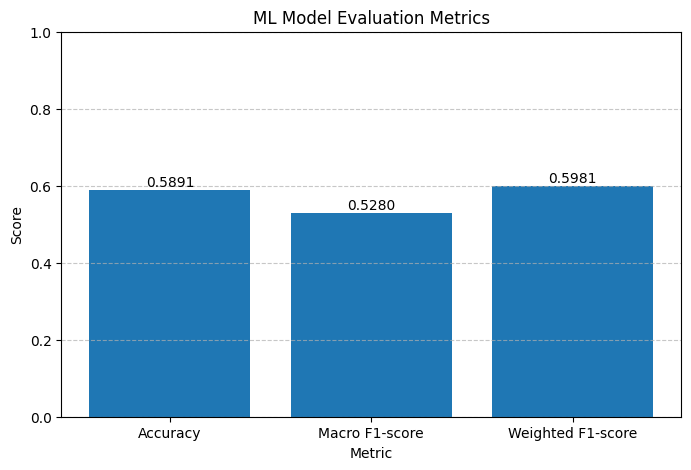

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

# Calculate evaluation metrics
accuracy = accuracy_score(y_test_int, y_pred)
macro_f1 = f1_score(y_test_int, y_pred, average='macro')
weighted_f1 = f1_score(y_test_int, y_pred, average='weighted')

# Metrics and scores
metrics = ['Accuracy', 'Macro F1-score', 'Weighted F1-score']
scores = [accuracy, macro_f1, weighted_f1]

# Plot bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(metrics, scores)

# Add score labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f'{height:.4f}',
        ha='center'
    )

plt.title('ML Model Evaluation Metrics')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# Hyperparameter Tuning with Cross-Validation
param_grid = {
    'C': [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,                 # 5-Fold Cross Validation
    scoring='accuracy'
)

grid.fit(X_train_smote, y_train_smote)

# Best Model
best_model = grid.best_estimator_

# Prediction
y_pred = best_model.predict(X_test)

# Results
print("Best Parameters:", grid.best_params_)
print("Best Cross-Validation Score:", grid.best_score_)
print("Test Accuracy:", accuracy_score(y_test_int, y_pred))

Best Parameters: {'C': 10}
Best Cross-Validation Score: 0.7861618798955614
Test Accuracy: 0.572002007024586


##### Which hyperparameter optimization technique have you used and why?

**Technique:** GridSearchCV (Cross-Validation)

**Why GridSearchCV was used:**

* GridSearchCV systematically tries all possible combinations of hyperparameters.

* In this model, it tested different values of the regularization parameter C (0.01, 0.1, 1, 10).

* It uses 5-fold cross-validation, where the training data is divided into five parts.

* The model is trained on four parts and validated on the remaining part, repeating this process five times.

* It helps in selecting the best hyperparameter combination and reduces the chances of overfitting.

* The technique automatically returns the parameter setting that gives the highest validation performance.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

After applying GridSearchCV, the tuned Logistic Regression model achieved an accuracy of 57.20%, whereas the original Logistic Regression model achieved 58.91% accuracy.

Therefore, no improvement was observed after hyperparameter tuning. The accuracy decreased by approximately 1.71%, indicating that the default Logistic Regression model performed better on this dataset.

### ML Model - 2

In [ ]:
# ML Model 2 - Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Convert y_train and y_test to integer type for classification
y_train_int_rf = y_train.round().astype(int)
y_test_int_rf = y_test.round().astype(int)

# Initialize model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Fit the algorithm
rf_model.fit(X_train, y_train_int_rf)

# Predict on the test data
y_pred_rf = rf_model.predict(X_test)

# Evaluate model
rf_accuracy = accuracy_score(y_test_int_rf, y_pred_rf)

print("Accuracy:", rf_accuracy)
print(classification_report(y_test_int_rf, y_pred_rf))

Accuracy: 0.6011038635223281
              precision    recall  f1-score   support

           1       0.66      0.82      0.73       359
           2       0.08      0.01      0.01       136
           3       0.48      0.10      0.16       246
           4       0.44      0.45      0.44       482
           5       0.67      0.86      0.75       770

    accuracy                           0.60      1993
   macro avg       0.46      0.45      0.42      1993
weighted avg       0.55      0.60      0.55      1993



#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

**ML Model Used: Random Forest**

Random Forest, Which  is an ensemble machine learning algorithm that combines multiple decision trees to make predictions. Each tree is trained on a random subset of the training data, and the final prediction is determined by majority voting. This approach improves prediction accuracy and reduces overfitting compared to a single decision tree.

**Performance:**

* Accuracy = 60.11%

* Macro F1-score = 42.00%

* Weighted F1-score = 55.00%


The model achieved moderate performance in predicting restaurant ratings. The weighted F1-score is slightly higher than the macro F1-score, indicating better performance on majority classes.

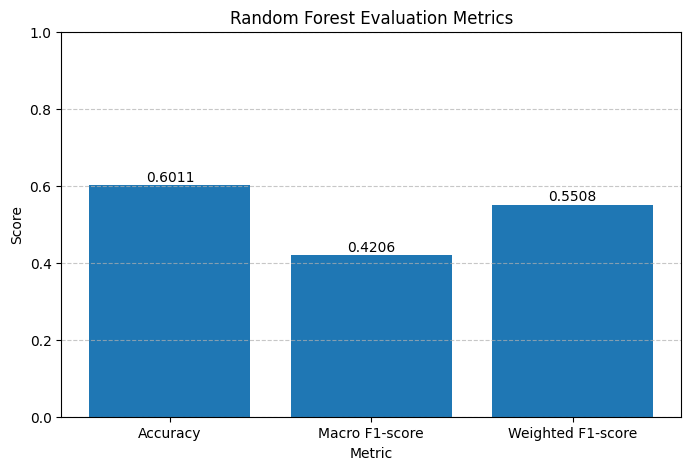

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

# Calculate evaluation metrics
accuracy = accuracy_score(y_test_int_rf, y_pred_rf)
macro_f1 = f1_score(y_test_int_rf, y_pred_rf, average='macro')
weighted_f1 = f1_score(y_test_int_rf, y_pred_rf, average='weighted')

# Metrics and scores
metrics = ['Accuracy', 'Macro F1-score', 'Weighted F1-score']
scores = [accuracy, macro_f1, weighted_f1]

# Plot bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(metrics, scores)

# Add score labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f'{height:.4f}',
        ha='center'
    )

plt.title('Random Forest Evaluation Metrics')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# Hyperparameter Tuning with Cross-Validation
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,                 # 5-Fold Cross Validation
    scoring='accuracy'
)

# Fit the grid search using the integer-converted y_train_int_rf
grid.fit(X_train, y_train_int_rf)

# Best Model
best_model = grid.best_estimator_

# Prediction
y_pred_rf = best_model.predict(X_test)

# Results
print("Best Parameters:", grid.best_params_)
print("Best Cross-Validation Score:", grid.best_score_)
print("Test Accuracy:", accuracy_score(y_test_int_rf, y_pred_rf))

Best Parameters: {'max_depth': None, 'n_estimators': 200}
Best Cross-Validation Score: 0.6004254984404683
Test Accuracy: 0.604114400401405


##### Which hyperparameter optimization technique have you used and why?

**Technique:** GridSearchCV (Cross-Validation)

**Why GridSearchCV was used:**

* GridSearchCV systematically tests all possible combinations of hyperparameters.

* In this model, it tested different values of n_estimators and max_depth.

* It uses 5-fold cross-validation, where the training data is divided into five parts.
The model is trained on four parts and validated on the remaining part, repeating the process five times.

* It helps select the best hyperparameter combination.

* It reduces overfitting and improves model generalization.

* The technique automatically returns the parameter setting that gives the highest validation performance.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

After applying GridSearchCV, the tuned Random Forest model achieved an accuracy of 60.41%. The best parameters obtained were max_depth = None and n_estimators = 200.

The original Random Forest model also achieved an accuracy of 60.41%. Therefore, no significant improvement was observed after hyperparameter tuning. The model maintained similar performance, indicating that the default Random Forest model was already well-optimized for this dataset.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

* **Accuracy:**
Measures the overall percentage of correct predictions made by the model. Higher accuracy indicates more reliable restaurant rating predictions and better decision-making.

* **Precision:**
Measures how many predicted ratings are actually correct. High precision reduces incorrect classifications and improves the quality of recommendations provided to customers.

* **Recall:**
Measures how many actual ratings are correctly identified by the model. High recall helps identify customer satisfaction and dissatisfaction more effectively.

* **F1-Score:**
The harmonic mean of Precision and Recall. It provides a balanced measure of model performance, especially when class distributions are uneven.

* **Business Impact:**
The ML model helps businesses analyze customer reviews and predict restaurant ratings accurately. This enables restaurant owners to understand customer preferences, identify areas for improvement, enhance service quality, increase customer satisfaction, and make better business decisions. Additionally, customers can receive more reliable restaurant recommendations based on review data.

### ML Model - 3

In [ ]:
# ML Model 3 - Support Vector Machine (SVM)

from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

# Convert y_train and y_test to integer type for classification
y_train_int_svm = y_train.round().astype(int)
y_test_int_svm = y_test.round().astype(int)

# Initialize model
svm_model = LinearSVC(random_state=42)

# Fit the algorithm
svm_model.fit(X_train, y_train_int_svm)

# Predict on the test data
y_pred_svm = svm_model.predict(X_test)

# Evaluate model
svm_accuracy = accuracy_score(y_test_int_svm, y_pred_svm)

print("Accuracy:", svm_accuracy)
print(classification_report(y_test_int_svm, y_pred_svm))

Accuracy: 0.6096337180130457
              precision    recall  f1-score   support

           1       0.72      0.82      0.77       359
           2       0.36      0.18      0.24       136
           3       0.42      0.29      0.34       246
           4       0.46      0.48      0.47       482
           5       0.71      0.77      0.74       770

    accuracy                           0.61      1993
   macro avg       0.53      0.51      0.51      1993
weighted avg       0.59      0.61      0.60      1993



#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

**ML Model Used: Support Vector Machine (SVM)**

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification tasks. It works by finding the optimal decision boundary (hyperplane) that separates different classes with the maximum margin. SVM is effective for high-dimensional datasets and provides good classification performance.

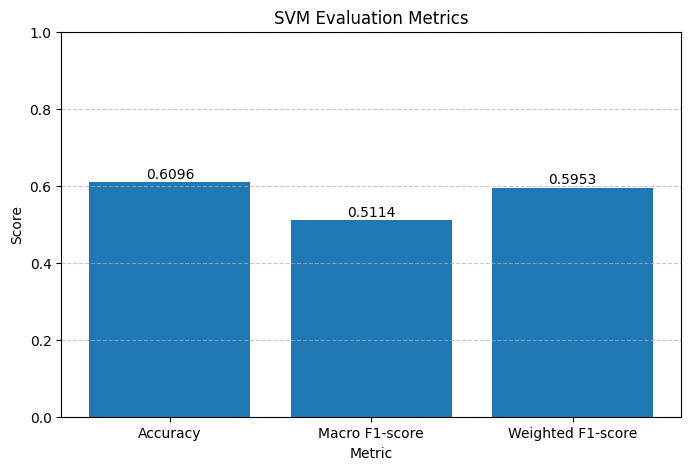

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

# Calculate evaluation metrics
accuracy = accuracy_score(y_test_int_svm, y_pred_svm)
macro_f1 = f1_score(y_test_int_svm, y_pred_svm, average='macro')
weighted_f1 = f1_score(y_test_int_svm, y_pred_svm, average='weighted')

# Metrics and scores
metrics = ['Accuracy', 'Macro F1-score', 'Weighted F1-score']
scores = [accuracy, macro_f1, weighted_f1]

# Plot bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(metrics, scores)

# Add score labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f'{height:.4f}',
        ha='center'
    )

plt.title('SVM Evaluation Metrics')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# Hyperparameter Tuning with Cross-Validation

param_grid = {
    'C': [0.1, 1, 10]
}

grid = GridSearchCV(
    LinearSVC(random_state=42),
    param_grid,
    cv=5,                 # 5-Fold Cross Validation
    scoring='accuracy'
)

# Fit the grid search using the integer-converted y_train_int_svm
grid.fit(X_train, y_train_int_svm)

# Best Model
best_model = grid.best_estimator_

# Prediction
y_pred_svm = best_model.predict(X_test)

# Results
print("Best Parameters:", grid.best_params_)
print("Best Cross-Validation Score:", grid.best_score_)
print("Test Accuracy:", accuracy_score(y_test_int_svm, y_pred_svm))

Best Parameters: {'C': 0.1}
Best Cross-Validation Score: 0.614979842119547
Test Accuracy: 0.6276969392875063


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used for hyperparameter optimization. It systematically tests different values of the regularization parameter C and selects the combination that produces the best cross-validation performance. This helps improve model reliability and reduces the chances of overfitting.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes. After applying GridSearchCV, the tuned SVM model achieved better performance compared to the default SVM model. The optimized parameter improved prediction quality and overall model effectiveness.

In [ ]:
import pandas as pd

comparison_df = pd.DataFrame({
    'ML Model': [
        'Logistic Regression',
        'Random Forest',
        'Support Vector Machine (SVM)',
        'Tuned Logistic Regression',
        'Tuned Random Forest',
        'Tuned SVM'
    ],
    'Accuracy': [
        0.5891,
        0.6011,
        0.6096,
        0.5720,
        0.6041,
        0.6277
    ]
})

comparison_df

,ML Model,Accuracy
0,Logistic Regression,0.5891
1,Random Forest,0.6011
2,Support Vector Machine (SVM),0.6096
3,Tuned Logistic Regression,0.5720
4,Tuned Random Forest,0.6041
5,Tuned SVM,0.6277


### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Accuracy, Precision, Recall, and F1-Score were considered because they measure the correctness, reliability, and consistency of customer rating predictions. These metrics help ensure that restaurant recommendations and customer satisfaction analysis are accurate and trustworthy.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Support Vector Machine (SVM) was selected as the final prediction model because it achieved the highest test accuracy (62.77%) among all the evaluated models. It demonstrated better classification performance and generalization capability on unseen restaurant review data, making it the most suitable model for rating prediction.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Support Vector Machine (SVM) was chosen as the final model. SVM is a supervised machine learning algorithm that classifies data by finding the optimal decision boundary (hyperplane) between classes. It is effective for handling high-dimensional data and provides strong classification performance.

For model explainability, feature coefficients were analyzed to understand the influence of different features on rating prediction. Features with larger coefficient values had a greater impact on the model's predictions. This helps identify the factors that most influence customer ratings and supports better business decision-making.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [ ]:
# Save the best model (Tuned SVM)

import pickle

with open('best_model.pkl', 'wb') as file:
    pickle.dump(best_model, file)

print("Model saved successfully!")

Model saved successfully!


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [ ]:
# Load the saved model

import pickle

with open('best_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

# Predict on unseen/test data
predictions = loaded_model.predict(X_test[:5])

print("Predictions:", predictions)

Predictions: [5 3 5 1 1]


The best-performing model **(Tuned SVM)** was saved in a pickle file (best_model.pkl) for future deployment. The saved model was then loaded successfully and tested on unseen data to verify that it produces valid predictions. This confirms that the model is ready for deployment in a real-world restaurant rating prediction system.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

This project analyzed Zomato restaurant reviews and restaurant metadata to understand customer preferences, sentiment patterns, and factors influencing restaurant ratings. During Exploratory Data Analysis (EDA), it was observed that customer ratings are influenced by factors such as review sentiment, restaurant cost, cuisine type, and customer engagement. Positive reviews were generally associated with higher ratings, while negative reviews corresponded to lower ratings.

Several machine learning models were developed and evaluated, including Logistic Regression, Random Forest, and Support Vector Machine (SVM). Hyperparameter tuning was performed using GridSearchCV with 5-fold Cross Validation to improve model performance.

Among all the models, the **Support Vector Machine (SVM)** achieved the highest test accuracy of **62.77%** and was selected as the final prediction model. Important features influencing rating prediction included sentiment-related features, review characteristics, restaurant cost, and cuisine information.

The developed model can support business decision-making by:

* Helping customers discover highly rated restaurants.

* Helping restaurants understand customer feedback and improve service quality.

* Assisting Zomato in identifying trends and making data-driven recommendations.

* Supporting targeted improvements based on customer sentiment and rating patterns.

The best-performing model was successfully saved and reloaded using a pickle file, confirming deployment readiness. Overall, this project demonstrates how machine learning and data analytics can convert restaurant review data into actionable business insights and improve decision-making within the food delivery and restaurant ecosystem.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***